# DATA LOADING

In [2]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from skimage.feature import hog
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [4]:
# Link raw GitHub
train_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-images-idx3-ubyte'
train_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-labels-idx1-ubyte'
test_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte'
test_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte'

import requests
import struct
import numpy as np

# Function to download files from a URL
def download_file(url, filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)

# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Tải dữ liệu từ GitHub
download_file(train_images_url, 'train-images-idx3-ubyte')
download_file(train_labels_url, 'train-labels-idx1-ubyte')
download_file(test_images_url, 't10k-images-idx3-ubyte')
download_file(test_labels_url, 't10k-labels-idx1-ubyte')

# Loading training data
train_images = load_images('train-images-idx3-ubyte')
train_labels = load_labels('train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('t10k-images-idx3-ubyte')
test_labels = load_labels('t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


##  Exploratory Data Analysis (EDA)

### Show label

In [5]:
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

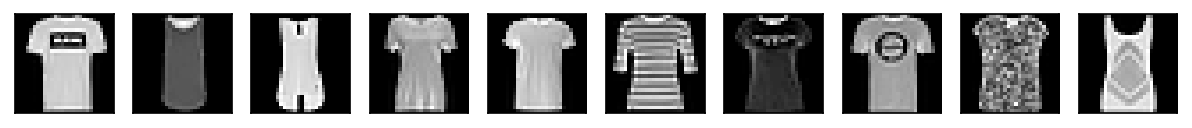

'label 1'

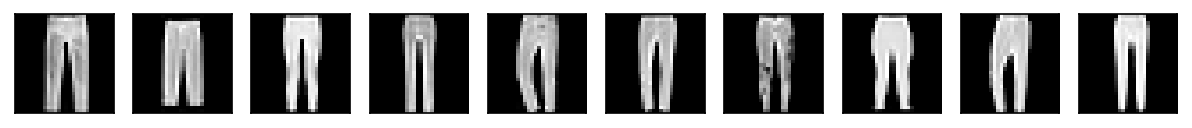

'label 2'

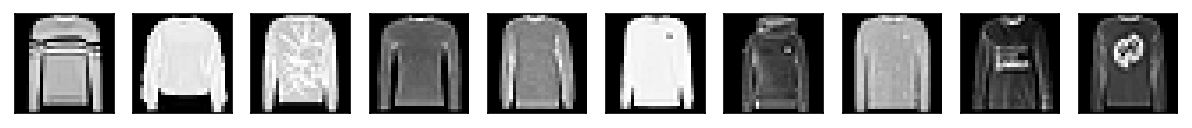

'label 3'

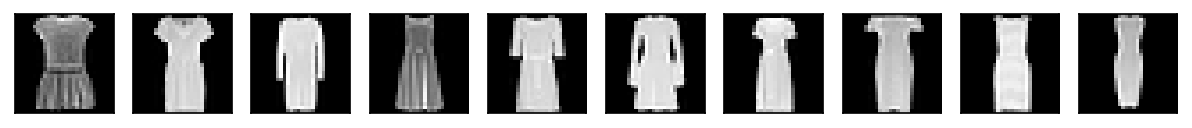

'label 4'

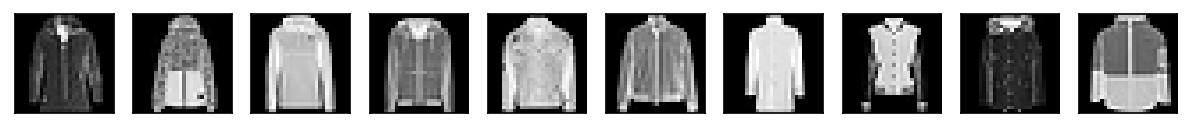

'label 5'

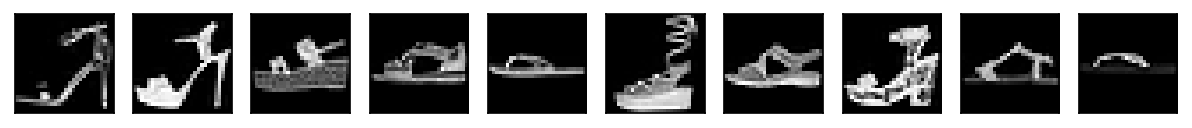

'label 6'

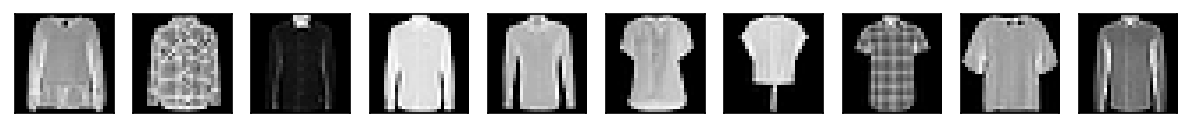

'label 7'

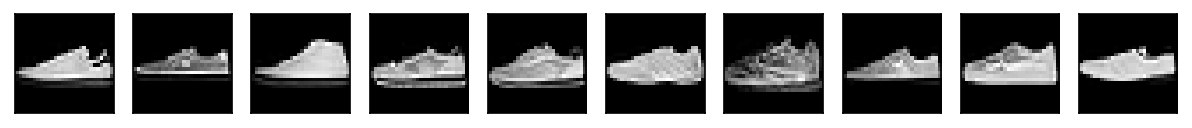

'label 8'

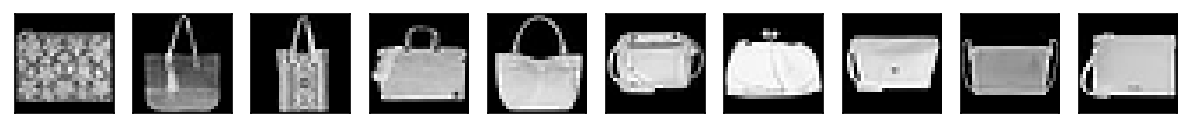

'label 9'

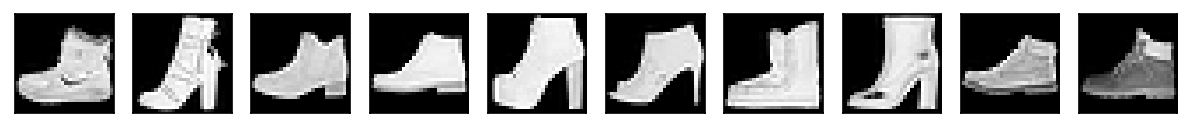

In [6]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

### Displays distribution and frequency of the data

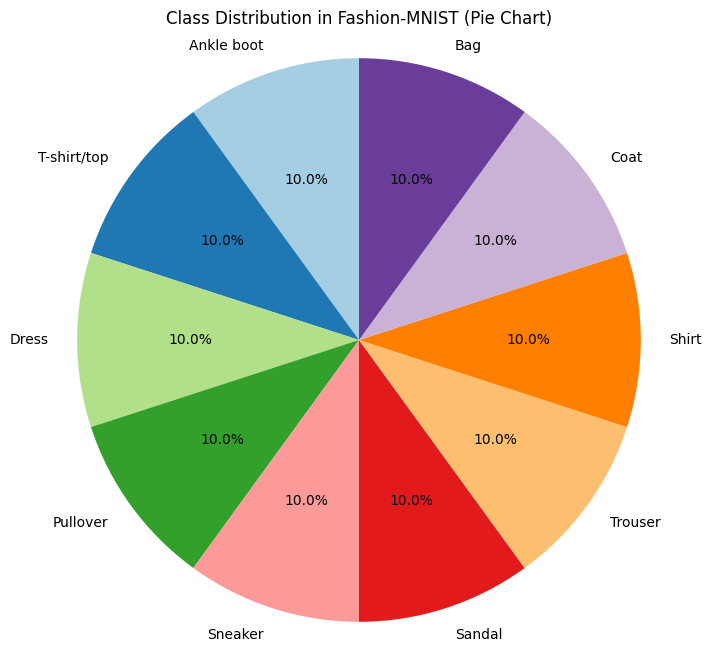

In [7]:
# List of class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def pie_chart_class_distribution(labels):
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Class Distribution in Fashion-MNIST (Pie Chart)')
    plt.axis('equal')
    plt.show()

# Distribution of train_lables
pie_chart_class_distribution(train_labels)

> The number of each layer is the same => **The dataset is balanced**

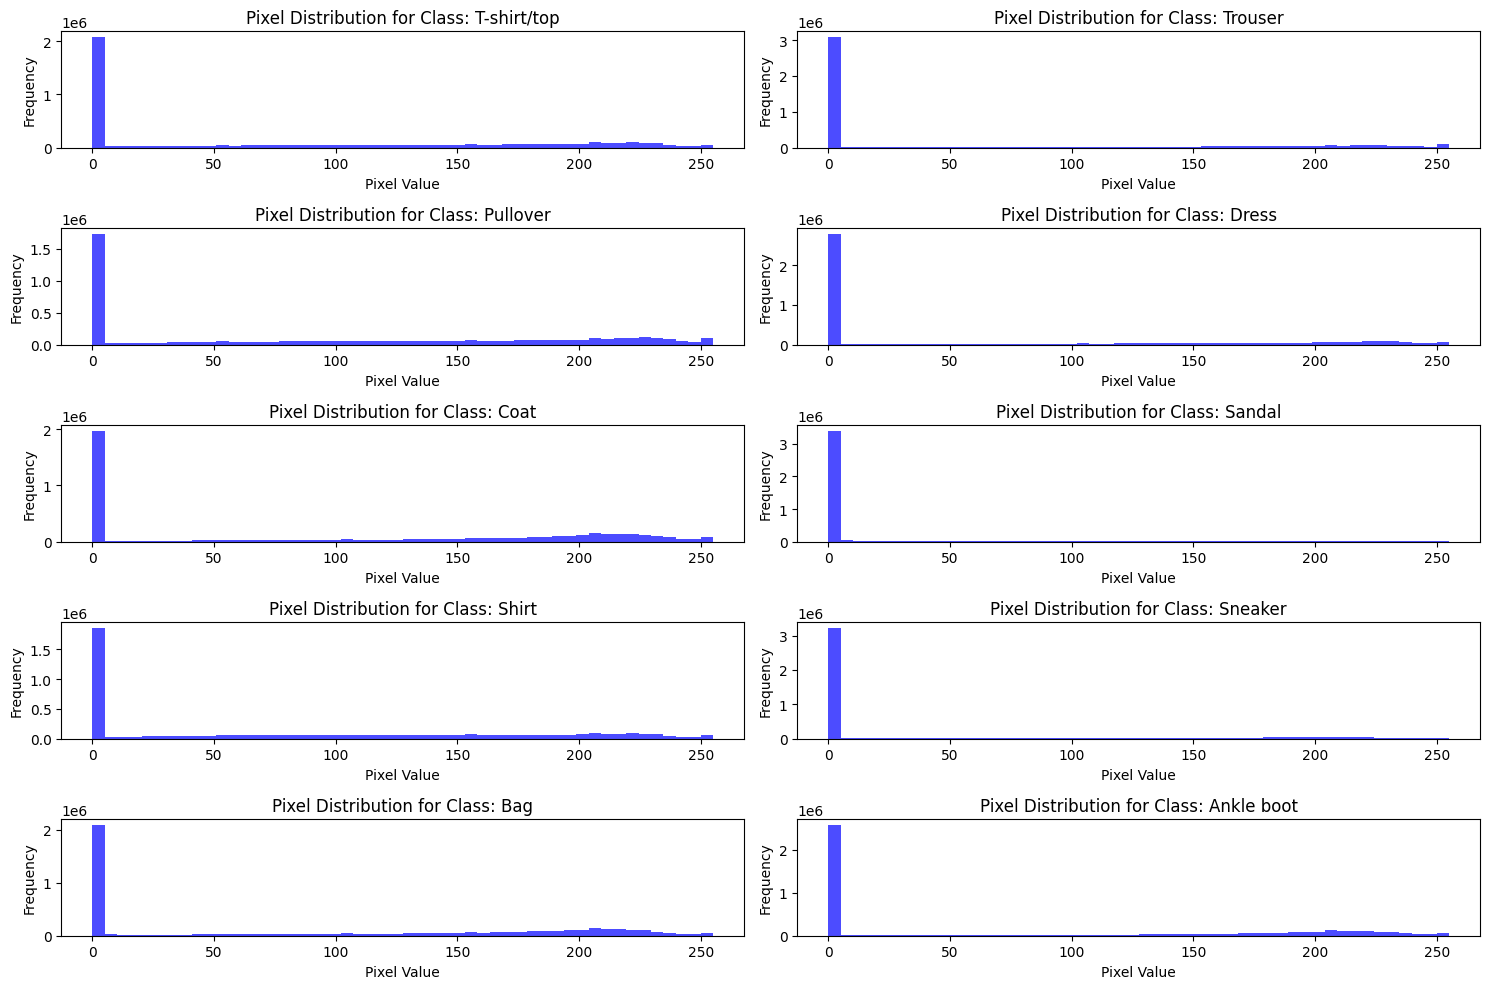

In [8]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images, train_labels, class_names)


>We can see **values .0** that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.

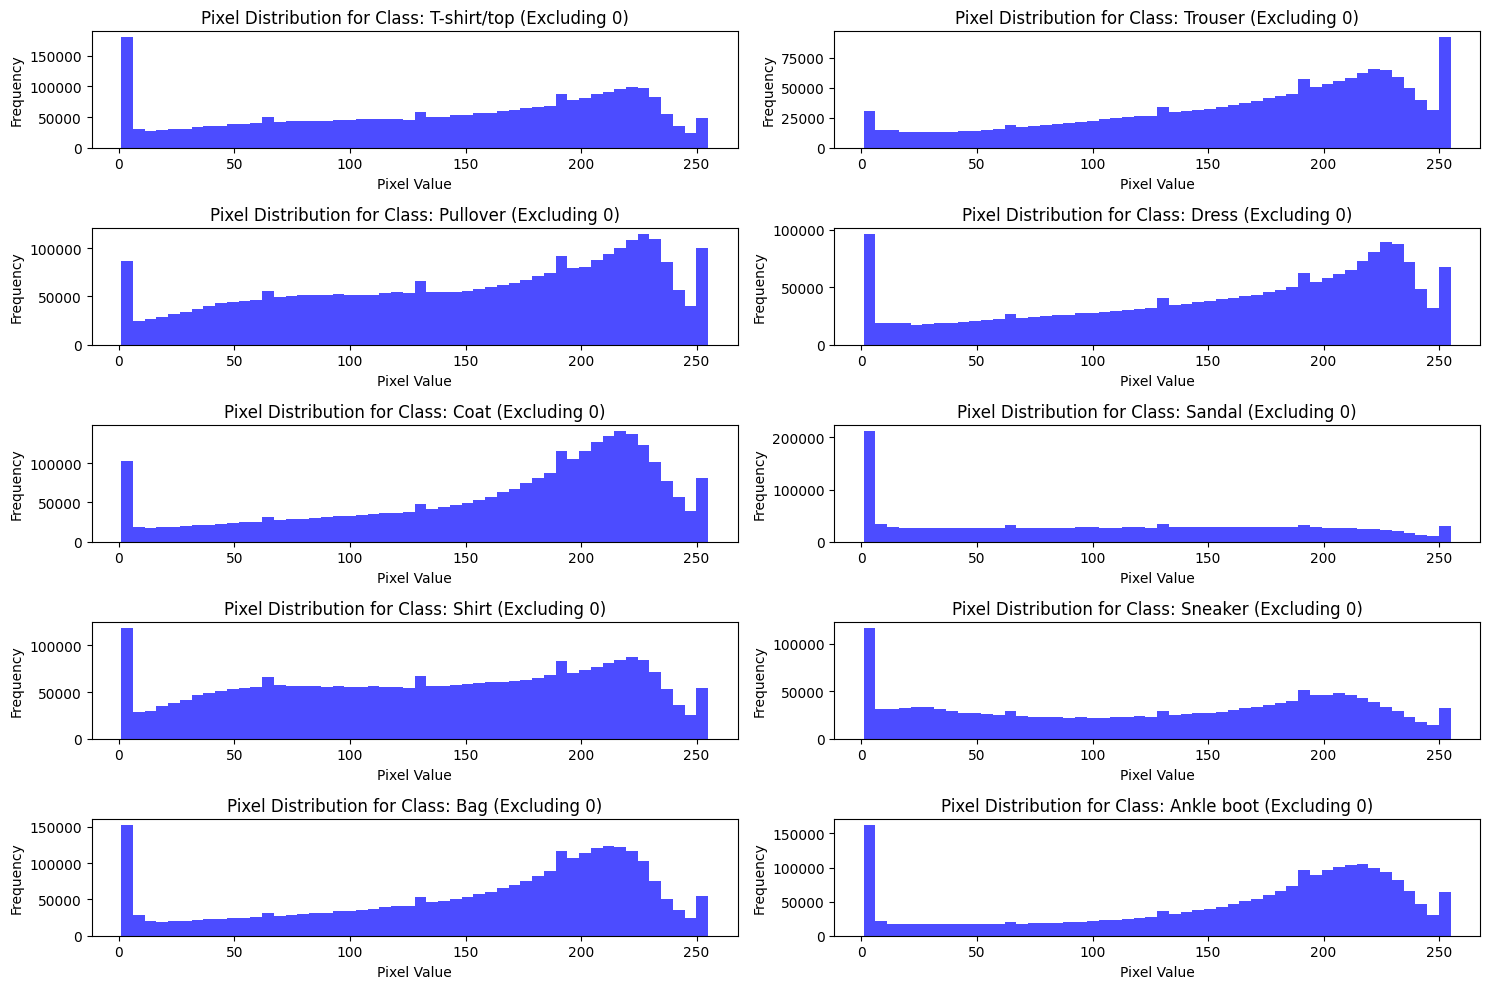

In [9]:
# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images, train_labels, class_names)

### Heat map for correlation label

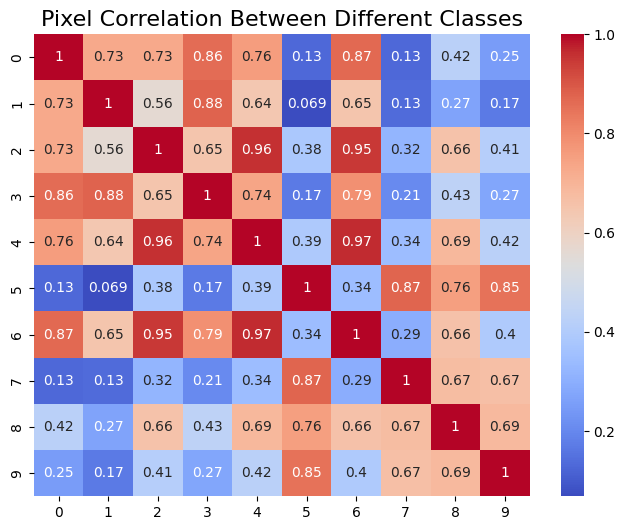

In [10]:
# Built correlation matrix

# Calculate the correlation matrix between classes
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_images[i])

# Calculate the average image of each layer
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Calculate the correlation matrix between classes
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

> The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes.

# PREPROCESSING

In [15]:
from cuml.linear_model import LogisticRegression as cuMLLogisticRegression
from cuml.metrics import accuracy_score, confusion_matrix
import cupy as cp
import time

In [16]:
# Chuyển dữ liệu từ numpy array sang cupy array để sử dụng GPU
train_images = cp.asarray(train_images)
train_labels = cp.asarray(train_labels,dtype=cp.int32)
test_images = cp.asarray(test_images)
test_labels = cp.asarray(test_labels, dtype=cp.int32)

In [17]:
from cuml.preprocessing import MinMaxScaler
import cupy as cp
scaler = MinMaxScaler()

In [18]:
train_images = scaler.fit_transform(train_images)
test_images = scaler.fit_transform(test_images)

## Linear Model - LogisticRegression

### Softmax Regression

cuML’s LogisticRegression can take array-like objects, either in host as NumPy arrays or in device (as Numba or __cuda_array_interface__ compliant), in addition to cuDF objects. It provides both single-class (using sigmoid loss) and multiple-class (using softmax loss) variants, depending on the input variables

In [20]:
# Huấn luyện mô hình Logistic Regression đa lớp (Softmax Regression)
model = cuMLLogisticRegression(max_iter=5000, solver='qn', fit_intercept=True)

start_time = time.time()
model.fit(train_images, train_labels)
end_time = time.time()
# Tính thời gian huấn luyện
training_time = end_time - start_time

print(f"Thời gian huấn luyện: {training_time:.2f} giây")

Thời gian huấn luyện: 77.85 giây


Accuracy: 0.8440999984741211


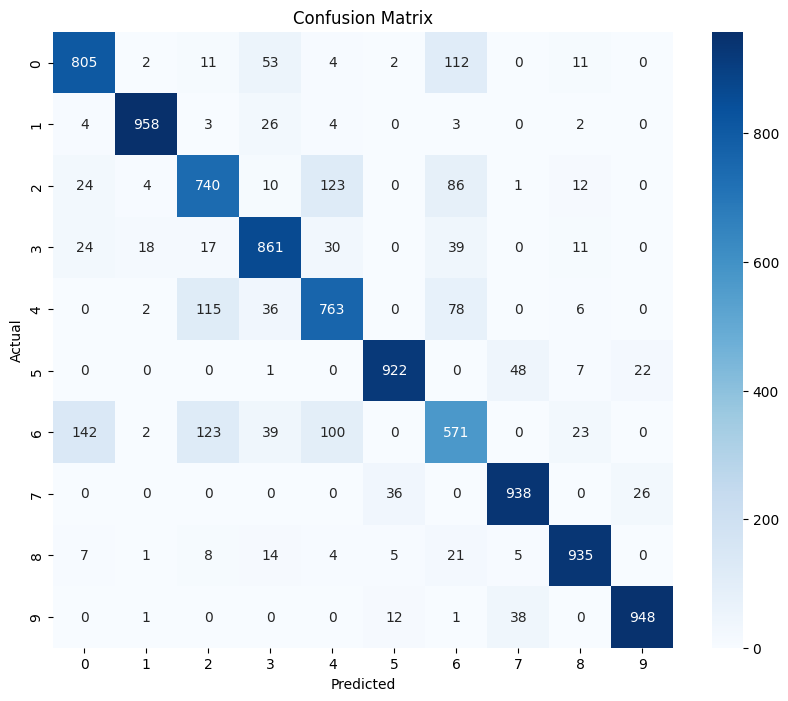

In [21]:
# Dự đoán trên tập test
test_predictions = model.predict(test_images)

# Đánh giá mô hình
accuracy = accuracy_score(test_labels, test_predictions)
print(f"Accuracy: {accuracy}")

# Ma trận nhầm lẫn
conf_matrix = confusion_matrix(test_labels, test_predictions)
conf_matrix = cp.asnumpy(conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()